In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

### Exercise 5.1

<br>

1) Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.

2) Pick data from the following columns to a second dataframe `df2`: `y`, `job`, `marital`, `default`, `housing`, `poutcome`.

3) Convert categorical variables to dummy numerical values using the command

`df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])`

4) Produce a heat map of correlation coefficients for all variables in `df3`. Describe the amount of correlation between the variables in your own words.

5) Select the column called `y` of `df3` as the target variable `y`, and all the remaining columns for the explanatory variables `X`.

6) Split the dataset into training and testing sets with 75/25  ratio.

7) Setup a logistic regression model, train it with training data and predict on testing data.

8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.


### Exercise 5.2

Consider the data from CSV file `weight-height.csv`.

1) Read data into a pandas dataframe.

2) Pick the target variable `y` as weight in kilograms, and the feature variable `X` as height in centimeters.

3) Split the data into training and testing sets with 80/20 ratio.

4) Scale the training and testing data using normalization and standardization.

5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.



In [26]:
#Exercise 5.1
#1)Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.
df = pd.read_csv("bank.csv", sep=";")  
print("Column Names")
print(df.columns.tolist())
print("\n Variable Types")
print(df.dtypes)


Column Names
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

 Variable Types
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [27]:
#2)Pick data from the following columns to a second dataframe df2: y, job, marital, default, housing, poutcome.
df2 = df[['y', 'job', 'marital', 'default', 'housing', 'poutcome']].copy()

In [28]:
#3) Convert categorical variables to dummy numerical values using the command
#df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])
if df2['y'].dtype == 'object':
    df2['y'] = df2['y'].map({'yes': 1, 'no': 0})

df3 = pd.get_dummies(df2, columns=['job', 'marital', 'default', 'housing', 'poutcome'], drop_first=True)

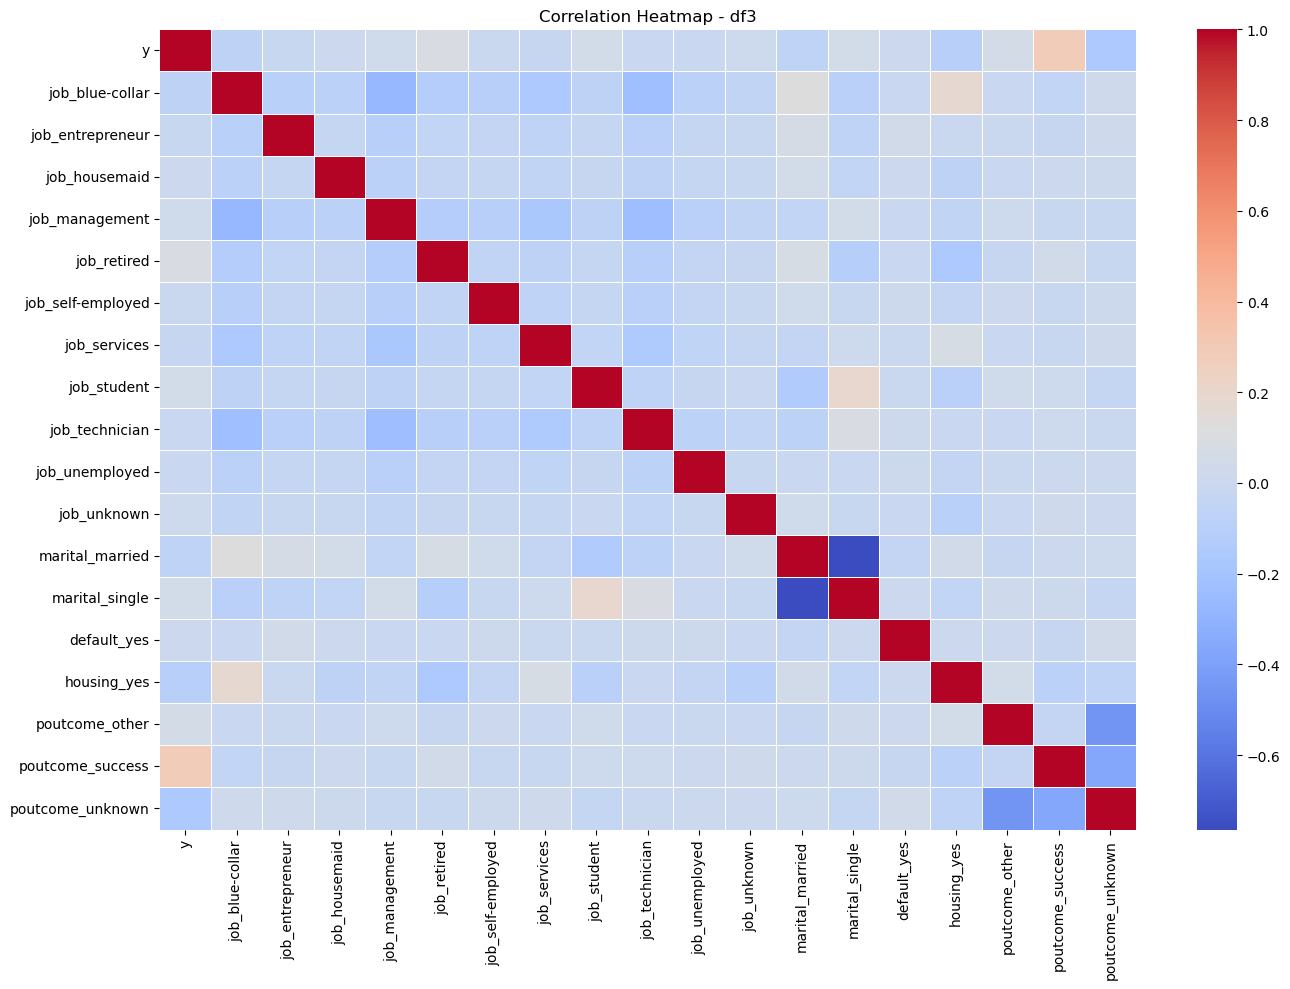

In [29]:
#4)Produce a heat map of correlation coefficients for all variables in df3. Describe the amount of correlation between the variables in your own words.
plt.figure(figsize=(14, 10))
sns.heatmap(df3.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - df3")
plt.tight_layout()
plt.show()

In [30]:
# 5) Select target variable y and explanatory variables X
X = df3.drop(columns=['y'])
y = df3['y']

In [31]:
# 6) Split the dataset into training and testing sets with 75/25 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [32]:
#7) Setup a logistic regression model, train it with training data and predict on testing data.
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

Accuracy Score: 0.8983
Confusion Matrix:
 [[997   9]
 [106  19]]


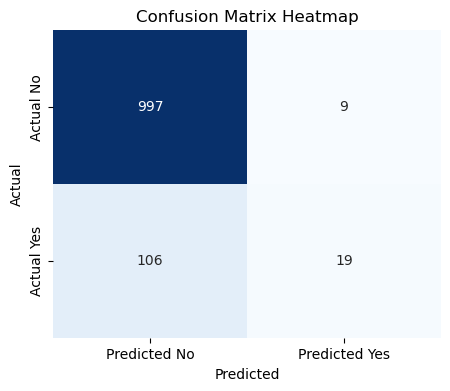

In [33]:
#8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("Confusion Matrix:\n", cm)

# Plot the heat map for the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title("Confusion Matrix Heatmap")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [35]:
#Exercise 5.2
#Consider the data from CSV file weight-height.csv.

#1)Consider the data from CSV file weight-height.csv.
df = pd.read_csv("weight-height.csv")
print(df)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [37]:
#2)Pick the target variable y as weight in kilograms, and the feature variable X as height in centimeters
X_height = (df[['Height']] * 2.54).values
y_weight = (df['Weight'] * 0.45359237).values

In [38]:
#3)Split the data into training and testing sets with 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X_height, y_weight, test_size=0.20, random_state=42) 

In [40]:
#4)Scale the training and testing data using normalization and standardization
#normal
norm_scaler = MinMaxScaler()
X_train_norm = norm_scaler.fit_transform(X_train)
X_test_norm = norm_scaler.transform(X_test)

#standard 
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

In [42]:
#5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.
knn_unscaled = KNeighborsRegressor(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
r2_unscaled = r2_score(y_test, y_pred_unscaled)

print(" KNN Regression Performance (k=5)")
print(f"R² Score on Unscaled Data: {r2_unscaled:.4f}")

 KNN Regression Performance (k=5)
R² Score on Unscaled Data: 0.8346
